<a href="https://colab.research.google.com/github/bysischpok/ML/blob/main/lab9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Лабораторная работа 9. Рекуррентные сети и трансформеры: архитектуры для последовательностей и текста

**Курс:** Машинное обучение. Безопасность ИИ-систем

**По материалам лекции 7**


**Вариант / seed:** _номер варианта или значение SEED_


### Таблица вариантов

| Вариант | `SEED` | `D_MODEL` | `N_MAX` (пар в обучении) | `D_CELL` | Температуры для части H |
|---|---|---|---|---|---|
| 1 | 42 | 64 | 12 | 48 | 0.5 / 1.0 / 1.5 |
| 2 | 7 | 48 | 10 | 40 | 0.4 / 1.0 / 1.6 |
| 3 | 123 | 64 | 8 | 48 | 0.6 / 1.0 / 1.4 |
| 4 | 2024 | 56 | 12 | 56 | 0.5 / 1.2 / 1.8 |
| 5 | 314 | 48 | 8 | 40 | 0.7 / 1.0 / 1.3 |
| 6 | 555 | 64 | 10 | 56 | 0.5 / 0.9 / 1.7 |

> Вариант выдаёт преподаватель. Все числа в отчёте должны соответствовать **вашему** варианту,
> а не значениям из примера в тексте.

### Цель работы

Экспериментально установить, чем механизм внимания отличается от рекуррентного накопления состояния,
какой ценой достигается каждое из свойств (точность вспоминания, стоимость контекста, память при
генерации), и какие архитектурные свойства становятся поверхностью атаки на языковые модели.

### Задачи

1. Реализовать BPE-токенизацию и оценить влияние уровня токенизации на длину последовательности.
2. Измерить затухание градиента в рекуррентной сети и сравнить мультипликативный путь с аддитивным.
3. Реализовать масштабированное скалярное внимание с каузальной маской.
4. Проверить численно, что RoPE зависит только от разности позиций, и построить штраф ALiBi.
5. Обучить двухслойный мини-трансформер задаче ассоциативного вспоминания и найти индукционную голову.
6. Реализовать линейное внимание в рекуррентной форме и сравнить его с softmax-вниманием.
7. Сделать рекуррентную ячейку избирательной и проверить, что это даёт управляемую память.
8. Реализовать top-k и top-p отсечение и оценить статистику многих попыток генерации.

### Порядок выполнения

1. Выполните ячейку настройки среды и впишите параметры своего варианта.
2. Идите по частям A–H подряд, заполняя каждый блок `TODO`.
3. После каждой части ответьте на вопрос в конце этой части (ячейка Markdown «Ответ»).
4. Заполните таблицы отчёта и сформулируйте выводы.
5. Перед сдачей выполните Kernel → Restart & Run All и убедитесь, что ошибок нет.

### Ограничение по безопасности

Работа не содержит и не должна содержать кода атак на реальные языковые модели и сервисы,
готовых строк обхода ограничений или инструментов автоматического подбора вредоносных запросов.
Часть H исследует **статистику выборки и архитектурные предпосылки** уязвимостей на игрушечной
модели — этого достаточно для понимания следующей лекции.

In [1]:
# Настройка окружения и единый стиль рисунков
import math, time, warnings
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import torch
import torch.nn as nn
import torch.nn.functional as F

warnings.filterwarnings("ignore")
torch.set_num_threads(2)

PALETTE = {"attn": "#2E86AB", "linear": "#F2A541", "bad": "#D6455F",
           "good": "#3FA46A", "accent": "#7B4FA0", "gray": "#8A94A6"}
CMAP_HEAT = LinearSegmentedColormap.from_list(
    "heat7", ["#0B1D33", "#2E86AB", "#F2E8CF", "#F2A541", "#D6455F"])

mpl.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 110, "font.size": 10.5,
    "axes.titlesize": 12, "axes.titleweight": "bold", "axes.labelsize": 10.5,
    "axes.grid": True, "grid.alpha": 0.25, "grid.linestyle": "--",
    "axes.spines.top": False, "axes.spines.right": False, "legend.frameon": False,
})

def finish(fig, title=None):
    if title:
        fig.suptitle(title, fontsize=13, fontweight="bold", y=0.995)
    fig.tight_layout(rect=(0, 0, 1, 0.96 if title else 1.0))
    plt.show()

print("torch:", torch.__version__, "| потоков:", torch.get_num_threads())

torch: 2.11.0+cpu | потоков: 2


In [19]:
# TODO 0: подставьте параметры СВОЕГО варианта из таблицы вариантов
SEED    = 555      # <-- ваш SEED
D_MODEL = 64      # <-- ваш D_MODEL
N_MAX   = 10      # <-- ваше число пар в обучении
D_CELL  = 56      # <-- ваша размерность рекуррентной ячейки
TAUS    = (0.5, 0.9, 1.7)   # <-- ваши температуры для части H

np.random.seed(SEED)
torch.manual_seed(SEED)
print("вариант: SEED=%d, D_MODEL=%d, N_MAX=%d, D_CELL=%d, TAUS=%s"
      % (SEED, D_MODEL, N_MAX, D_CELL, str(TAUS)))

вариант: SEED=555, D_MODEL=64, N_MAX=10, D_CELL=56, TAUS=(0.5, 0.9, 1.7)


## Часть A. Токенизация: BPE с нуля

Модель работает не с буквами и не со словами, а с токенами. Уровень токенизации задаёт длину
последовательности $n$, а значит и стоимость внимания $O(n^2)$, а также распределение частот:
редкие токены остаются недообученными.

**Задание A.1.** Реализуйте один шаг BPE: подсчёт частот пар соседних символов и слияние самой
частой пары.
**Задание A.2.** Обучите BPE на корпусе и измерьте коэффициенты сжатия «символы → BPE» и
«BPE → слова».
**Задание A.3.** Постройте график длины корпуса в токенах от числа выполненных слияний и
распределение частот токенов в логарифмических осях; отметьте порог редких токенов
`RARE_THR` (частота не выше `RARE_THR` за весь корпус).

In [3]:
CORPUS = (
    "внимание позволяет модели обращаться к любой позиции последовательности напрямую. "
    "рекуррентная сеть накапливает состояние и постепенно теряет информацию о далёком прошлом. "
    "трансформер обучается параллельно по всем позициям и потому масштабируется. "
    "позиционное кодирование сообщает модели порядок токенов. "
    "линейное внимание заменяет матрицу внимания рекуррентным состоянием. "
    "избирательная рекуррентность делает затухание зависящим от входа. "
    "квантование и кэширование уменьшают стоимость генерации. "
) * 6

words = CORPUS.split()
vocab_words = {}
for w in words:
    key = tuple(w) + ("</w>",)
    vocab_words[key] = vocab_words.get(key, 0) + 1

def pair_counts(vocab):
    counts = {}
    for seq, freq in vocab.items():
        for i in range(len(seq) - 1):
            counts[(seq[i], seq[i + 1])] = counts.get((seq[i], seq[i + 1]), 0) + freq
    return counts

def merge_pair(vocab, pair):
    a, b = pair
    merged = a + b
    new_vocab = {}
    for seq, freq in vocab.items():
        new_seq, i = [], 0
        while i < len(seq):
            if i < len(seq) - 1 and seq[i] == a and seq[i + 1] == b:
                new_seq.append(merged); i += 2
            else:
                new_seq.append(seq[i]); i += 1
        new_vocab[tuple(new_seq)] = freq
    return new_vocab

print("слов в корпусе:", len(words), "| уникальных словоформ:", len(vocab_words))

слов в корпусе: 330 | уникальных словоформ: 51


In [4]:
# TODO A.2: выполните N_MERGES слияний, на каждом шаге сохраняя длину корпуса в токенах
N_MERGES = 120
vocab = dict(vocab_words)
lengths = [sum(len(seq) * freq for seq, freq in vocab.items())]
merges = []

# TODO A.2a: цикл слияний: pair_counts -> самая частая пара -> merge_pair
#            длина корпуса = sum(len(seq) * freq for seq, freq in vocab.items())
for _ in range(N_MERGES):
    pc = pair_counts(vocab)
    if not pc:
        break
    best = max(pc, key=pc.get)
    vocab = merge_pair(vocab, best)
    merges.append(best)
    lengths.append(sum(len(seq) * freq for seq, freq in vocab.items()))
# TODO A.2b: посчитайте и напечатайте коэффициенты сжатия
n_chars = len(CORPUS.replace(" ", ""))
n_bpe = lengths[-1]
n_words = len(words)
print(f"символов: {n_chars} | BPE-токенов: {n_bpe} | слов: {n_words}")
print(f"сжатие символы→BPE: {n_chars / n_bpe:.2f}×")
print(f"BPE на слово: {n_bpe / n_words:.2f}")
print(f"размер словаря: {len(set(t for seq in vocab for t in seq))}")

символов: 2652 | BPE-токенов: 1152 | слов: 330
сжатие символы→BPE: 2.30×
BPE на слово: 3.49
размер словаря: 92


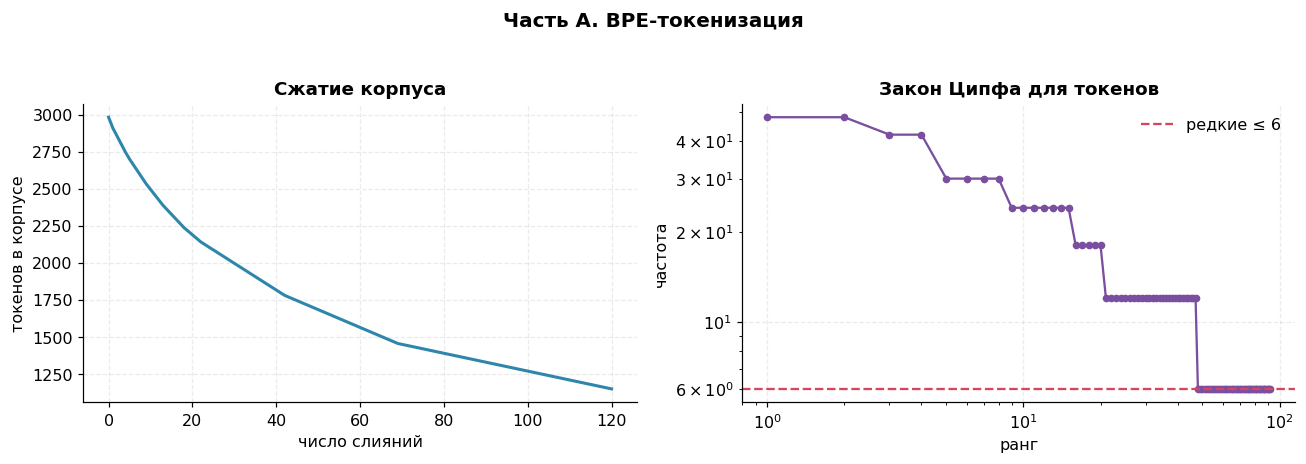

редких токенов: 45 (48.9% словаря)


In [5]:
# TODO A.3: рисунок A: длина корпуса от числа слияний + частоты токенов (закон Ципфа)
# слева: lengths от номера слияния
# справа: отсортированные по убыванию частоты токенов в log-log осях,
#         отметьте горизонтальной линией порог «редкий токен» (частота <= RARE_THR)
RARE_THR = 6
token_freq = {}
for seq, freq in vocab.items():
    for t in seq:
        token_freq[t] = token_freq.get(t, 0) + freq
freqs = np.array(sorted(token_freq.values(), reverse=True))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
axes[0].plot(range(len(lengths)), lengths, color=PALETTE["attn"], linewidth=2)
axes[0].set_xlabel("число слияний"); axes[0].set_ylabel("токенов в корпусе")
axes[0].set_title("Сжатие корпуса")

ranks = np.arange(1, len(freqs) + 1)
axes[1].loglog(ranks, freqs, "o-", color=PALETTE["accent"], markersize=4)
axes[1].axhline(RARE_THR, color=PALETTE["bad"], linestyle="--", label=f"редкие ≤ {RARE_THR}")
axes[1].set_xlabel("ранг"); axes[1].set_ylabel("частота")
axes[1].set_title("Закон Ципфа для токенов")
axes[1].legend()
finish(fig, "Часть A. BPE-токенизация")

n_rare = int((freqs <= RARE_THR).sum())
print(f"редких токенов: {n_rare} ({n_rare / len(freqs):.1%} словаря)")

**Вопрос A.** Во сколько раз выросла бы стоимость слоя внимания, если перейти от BPE к посимвольной
токенизации при том же тексте? Используйте измеренный коэффициент сжатия и зависимость $O(n^2)$.

**Ответ A.**  
На данном примере стоимость посимвольной токенизации увеличилась в 5.3 раза, так как стоимость BPE = 2.3х ($O(n)$ против $O(n^2)$)

## Часть B. Затухание градиента в рекуррентной сети

Для рекуррентности $h_t = \phi(W h_{t-1} + U x_t)$ производная по состоянию, удалённому на $k$ шагов,
содержит произведение $k$ матриц:

$
\frac{\partial h_T}{\partial h_{T-k}} = \prod_{j=0}^{k-1} \operatorname{diag}(\phi')\, W .
$

Норма такого произведения ведёт себя как $\rho(W)^k$. Аддитивный путь с гейтом $f_t$ даёт вместо
этого множитель $\prod f_t$, который при $f_t \to 1$ почти не затухает.

**Задание B.1.** Вычислите норму произведения $k$ матриц с заданным спектральным радиусом.
**Задание B.2.** Постройте график нормы от $k$ для $\rho \in \{0.9, 1.0, 1.2\}$ и добавьте
аддитивные пути с $f_t = 0.99$ и $f_t = 0.95$.
**Задание B.3.** Найдите эффективный горизонт памяти: при каком $k$ норма падает ниже $10^{-6}$.

In [6]:
def make_W(d, rho, gen):
    # матрица со заданным спектральным радиусом
    A = gen.normal(size=(d, d)) / np.sqrt(d)
    return A * rho / np.max(np.abs(np.linalg.eigvals(A)))

def grad_norms(rho, k_max=120, d=32, seed=0):
    # TODO B.1: верните массив норм произведения k матриц W для k = 1..k_max
    #           используйте np.linalg.norm(P, 2) и накопление P = P @ W
    gen = np.random.default_rng(seed)
    W = make_W(d, rho, gen)
    norms, P = [], np.eye(d)
    for _ in range(k_max):
        P = P @ W
        norms.append(np.linalg.norm(P, 2))
    return np.array(norms)

def horizon(rho, thr=1e-6, k_max=4000, d=32, seed=0):
    # TODO B.3: верните наименьшее k, при котором норма падает ниже thr
    #           (оценивайте норму как rho ** k, чтобы не перемножать тысячи матриц)
    if rho >= 1.0:
        return k_max
    return int(np.ceil(np.log(thr) / np.log(rho)))

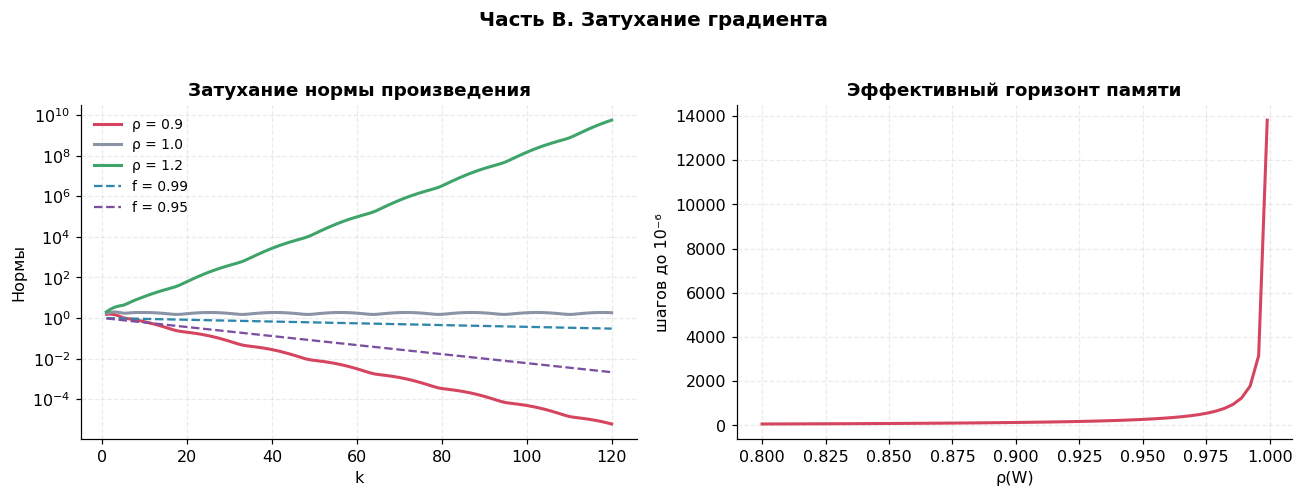

In [8]:
# TODO B.2: рисунок B: слева нормы от k в логарифмической шкале для трёх значений rho
#           и две линии аддитивного пути f**k (f = 0.99 и 0.95);
#           справа эффективный горизонт памяти horizon(rho) для rho от 0.8 до 0.999
ks = np.arange(1, 121)
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

for rho, color in [(0.9, PALETTE["bad"]), (1.0, PALETTE["gray"]), (1.2, PALETTE["good"])]:
    axes[0].semilogy(ks, grad_norms(rho), color=color, linewidth=2, label=f"ρ = {rho}")
axes[0].semilogy(ks, 0.99 ** ks, "--", color=PALETTE["attn"], label="f = 0.99")
axes[0].semilogy(ks, 0.95 ** ks, "--", color=PALETTE["accent"], label="f = 0.95")
axes[0].set_xlabel("k"); axes[0].set_ylabel("Нормы")
axes[0].set_title("Затухание нормы произведения")
axes[0].legend(fontsize=9)

rhos = np.linspace(0.8, 0.999, 60)
hor = [horizon(r) for r in rhos]
axes[1].plot(rhos, hor, color=PALETTE["bad"], linewidth=2)
axes[1].set_xlabel("ρ(W)"); axes[1].set_ylabel("шагов до 10⁻⁶")
axes[1].set_title("Эффективный горизонт памяти")
finish(fig, "Часть B. Затухание градиента")

**Вопрос B.** Пусть требуется удерживать зависимость длиной 500 шагов с ослаблением сигнала не
более чем в 10 раз. Какое значение гейта $f_t$ для этого нужно? Сравните с $\rho(W)$, необходимым в
чистой рекуррентности.

**Ответ B.**  
Для удержания сигнала на 500 шагов с ослаблением не более чем в 10 раз: f^500 = 0.1, значит f = 0.1^(1/500) = 0.9954  
Для чистой рекуррентности нужен ρ(W) ≥ 0.9954. Это соответствует границе устойчивости: при ρ > 1 градиенты взрываются, при ρ < 1 — затухают.

## Часть C. Внимание с нуля и роль масштабирования

$
\operatorname{Attention}(Q,K,V) = \operatorname{softmax}\!\left(\frac{QK^{\top}}{\sqrt{d_k}}\right) V .
$

Делитель $\sqrt{d_k}$ не косметика: при $q,k \sim \mathcal N(0,1)$ скалярное произведение имеет
дисперсию $d_k$, и без нормировки softmax при больших $d_k$ вырождается почти в one-hot, что
обнуляет градиент по ключам.

**Задание C.1.** Реализуйте одну голову внимания с каузальной маской и без неё.
**Задание C.2.** Проверьте два обязательных свойства: строки матрицы внимания суммируются в единицу,
а при каузальной маске верхний треугольник строго нулевой.
**Задание C.3.** Измерьте среднюю энтропию распределения внимания как функцию $d_k$ с делителем и
без него, постройте рисунок с картами внимания и графиком энтропии.

In [10]:
def attention(Q, K, V, causal=True, scale=True):
    # TODO C.1: реализуйте scaled dot-product attention
    #   1) scores = Q @ K.T
    #   2) если scale: разделите на sqrt(d_k)
    #   3) если causal: запретите будущее (значение -inf выше главной диагонали)
    #   4) softmax по последней оси устойчивым способом (вычтите максимум строки)
    #   верните (результат, матрица_внимания)
    Q, K, V = np.asarray(Q), np.asarray(K), np.asarray(V)
    d_k = Q.shape[-1]
    scores = Q @ K.T
    if scale:
        scores = scores / np.sqrt(d_k)
    if causal:
        n = scores.shape[0]
        mask = np.triu(np.ones((n, n), dtype=bool), k=1)
        scores = np.where(mask, -np.inf, scores)
    scores = scores - scores.max(axis=-1, keepdims=True)
    e = np.exp(scores)
    attn = e / e.sum(axis=-1, keepdims=True)
    return attn @ V, attn

def mean_entropy(d_k, scale, n=64, trials=40, seed=0):
    # TODO C.3a: средняя энтропия строк матрицы внимания для случайных Q, K
    gen = np.random.default_rng(seed)
    ents = []
    for _ in range(trials):
        Q = gen.normal(size=(n, d_k))
        K = gen.normal(size=(n, d_k))
        V = gen.normal(size=(n, d_k))
        _, W = attention(Q, K, V, causal=False, scale=scale)
        ent = -(W * np.log(W + 1e-12)).sum(axis=-1).mean()
        ents.append(ent)
    return float(np.mean(ents))

In [11]:
# TODO C.2: проверка свойств внимания
g = np.random.default_rng(SEED)
Qt, Kt, Vt = g.normal(size=(8, 16)), g.normal(size=(8, 16)), g.normal(size=(8, 3))
_, Wt = attention(Qt, Kt, Vt, causal=True, scale=True)
# TODO C.2a: проверьте, что суммы по строкам равны 1 (assert)
# TODO C.2b: проверьте, что верхний треугольник (без диагонали) равен 0 (assert)
# TODO C.2c: напечатайте максимальное отклонение сумм строк от единицы
assert np.allclose(Wt.sum(axis=-1), 1.0), "строки должны суммироваться в 1"
assert np.allclose(Wt[np.triu_indices(8, k=1)], 0.0), "верхний треугольник должен быть 0"
print("макс. отклонение сумм строк от 1:", np.abs(Wt.sum(axis=-1) - 1).max())

макс. отклонение сумм строк от 1: 2.220446049250313e-16


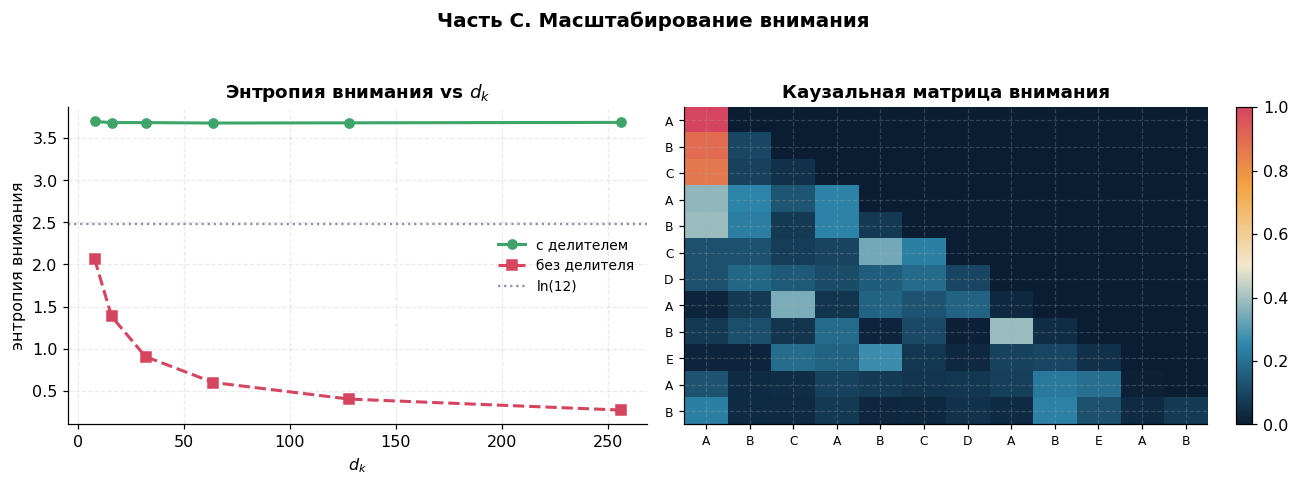

In [12]:
# TODO C.3b: рисунок C:
#   верхний ряд — три карты внимания: двунаправленная, каузальная, без делителя (Q*4, K*4)
#   нижний ряд — энтропия внимания от d_k с делителем и без, с линией ln(64)
# используйте последовательность labels ниже: повторяющийся паттерн даёт наглядные карты
n_tok, d_k = 12, 16
labels = ["A", "B", "C", "A", "B", "C", "D", "A", "B", "E", "A", "B"]
gen_c = np.random.default_rng(SEED)

def make_qkv(n, d, seed):
    g = np.random.default_rng(seed)
    return g.normal(size=(n, d)), g.normal(size=(n, d)), g.normal(size=(n, d))

Q1, K1, V1 = make_qkv(n_tok, d_k, SEED)
_, W_bi = attention(Q1, K1, V1, causal=False, scale=True)
_, W_ca = attention(Q1, K1, V1, causal=True, scale=True)

Q2 = Q1 * 4
K2 = K1 * 4
_, W_no = attention(Q2, K2, V1, causal=False, scale=False)

d_list = [8, 16, 32, 64, 128, 256]
ent_s = [mean_entropy(d, True) for d in d_list]
ent_n = [mean_entropy(d, False) for d in d_list]

fig, axes = plt.subplots(1, 2, figsize=(12, 4.4))
axes[0].plot(d_list, ent_s, "o-", color=PALETTE["good"], linewidth=2, label="с делителем")
axes[0].plot(d_list, ent_n, "s--", color=PALETTE["bad"], linewidth=2, label="без делителя")
axes[0].axhline(np.log(n_tok), ls=":", color=PALETTE["gray"], label=f"ln({n_tok})")
axes[0].set_xlabel("$d_k$"); axes[0].set_ylabel("энтропия внимания")
axes[0].set_title("Энтропия внимания vs $d_k$")
axes[0].legend(fontsize=9)

im = axes[1].imshow(W_ca, cmap=CMAP_HEAT, aspect="auto", vmin=0, vmax=1)
axes[1].set_title("Каузальная матрица внимания")
axes[1].set_xticks(range(n_tok)); axes[1].set_xticklabels(labels, fontsize=8)
axes[1].set_yticks(range(n_tok)); axes[1].set_yticklabels(labels, fontsize=8)
plt.colorbar(im, ax=axes[1], fraction=0.046)
finish(fig, "Часть C. Масштабирование внимания")

**Вопрос C.** Почему вырождение softmax в one-hot останавливает обучение? Свяжите ответ с
производной softmax по логитам.

**Ответ C.**  
Softmax вырождается в one-hot, когда логиты имеют большой разброс. Производная softmax обнуляется по всем неглавным элементам, потому что все компоненты p кроме одной равны нулю. Градиент по ключам становится равным нулю, обучение останавливается. Делитель √d_k компенсирует рост дисперсии скалярного произведения с размерностью и сохраняет softmax в «мягком» режиме.

## Часть D. Позиционные кодировки: синусоида, RoPE, ALiBi

Внимание перестановочно инвариантно, поэтому порядок вносится отдельно:

- синусоидальная кодировка добавляется к эмбеддингу (абсолютная позиция);
- **RoPE** поворачивает $q$ и $k$ на угол, пропорциональный позиции, так что
  $\langle R_t q, R_s k\rangle = f(q,k,t-s)$;
- **ALiBi** добавляет к логитам линейный штраф $-m|t-s|$.

**Задание D.1.** Реализуйте синусоидальную кодировку.
**Задание D.2.** Реализуйте RoPE и численно проверьте зависимость только от $t-s$: постройте
$\langle R_{t}q, R_{s}k\rangle$ для нескольких абсолютных начал при одинаковых разностях позиций.
**Задание D.3.** Постройте матрицу штрафов ALiBi для одной головы и рисунок из трёх панелей.

In [15]:
def sinusoidal(n, d):
    # TODO D.1: чётные каналы — sin(pos / 10000^(i/d)), нечётные — cos от того же аргумента
    pos = np.arange(n)[:, None]
    i = np.arange(d)[None, :]
    angle = pos / (10000 ** ( i / d))
    return np.where(i % 2 == 0, np.sin(angle), np.cos(angle)).astype(np.float32)

def rope_apply(x, pos, base=10000.0):
    # TODO D.2: поверните пары координат (первая половина, вторая половина) на угол
    #           theta_i = pos / base ** (2i/d):
    #           x1' = x1*cos - x2*sin,  x2' = x1*sin + x2*cos
    d = x.shape[-1]
    half = d // 2
    i = np.arange(half)
    theta = pos / (base ** (2 * i / d))
    cos_t, sin_t = np.cos(theta), np.sin(theta)
    x1, x2 = x[..., :half], x[..., half:]
    return np.concatenate([x1 * cos_t - x2 * sin_t, x1 * sin_t + x2 * cos_t], axis=-1)

# TODO D.2a: проверьте инвариантность к сдвигу абсолютных позиций и напечатайте расхождение
gen_d = np.random.default_rng(SEED)
d_rope = 16
q_vec = gen_d.normal(size=(d_rope,))
k_vec = gen_d.normal(size=(d_rope,))

for delta in [1, 3, 7, 15]:
    vals = []
    for t in range(delta, 40):
        s = t - delta
        q_t = rope_apply(q_vec[None, :], t)[0]
        k_s = rope_apply(k_vec[None, :], s)[0]
        vals.append(np.dot(q_t, k_s))
    vals = np.array(vals)
    print(f"delta={delta}: разброс = {np.std(vals):.2e}")

delta=1: разброс = 2.07e-15
delta=3: разброс = 7.37e-16
delta=7: разброс = 9.40e-16
delta=15: разброс = 5.89e-16


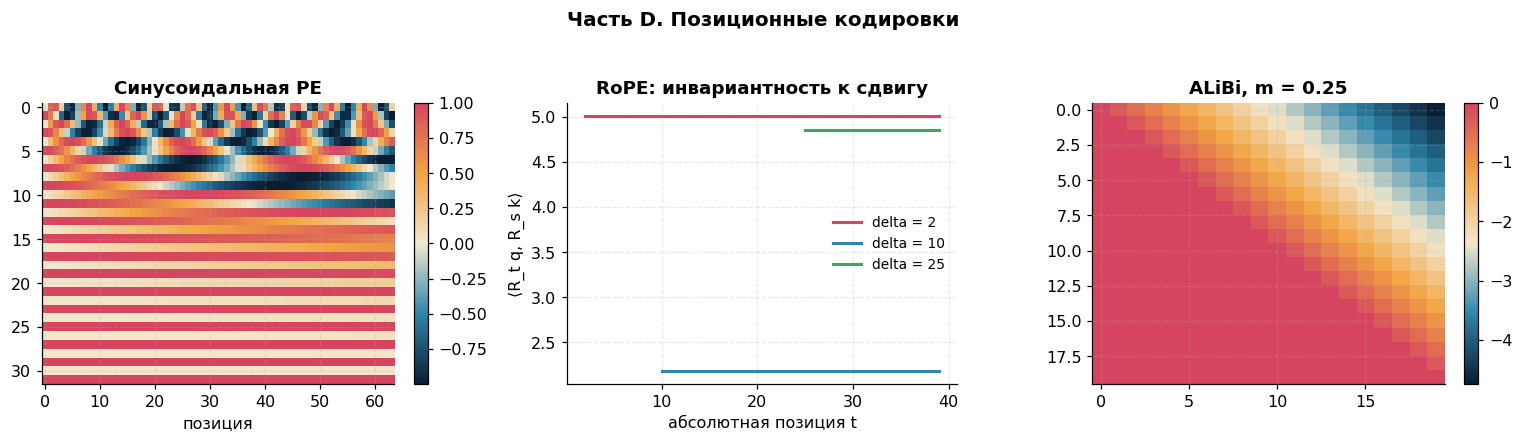

In [16]:
# TODO D.3: рисунок D: (1) карта синусоидальной кодировки, (2) кривые RoPE для разных абсолютных
# начал, (3) матрица штрафов ALiBi (наклоны m_h = 2^{-h}, запрещённое будущее оставьте пустым)
pe = sinusoidal(64, 32)
n_alibi = 20
m_h = 0.25
alibi = -m_h * np.abs(np.arange(n_alibi)[:, None] - np.arange(n_alibi)[None, :])
alibi = np.triu(alibi, k=0)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
im0 = axes[0].imshow(pe.T, cmap=CMAP_HEAT, aspect="auto")
axes[0].set_title("Синусоидальная PE"); axes[0].set_xlabel("позиция")
plt.colorbar(im0, ax=axes[0], fraction=0.046)

for d0, color in [(2, PALETTE["bad"]), (10, PALETTE["attn"]), (25, PALETTE["good"])]:
    vals = []
    ts = np.arange(d0, 40)
    for t in ts:
        s = t - d0
        q_t = rope_apply(q_vec[None, :], t)[0]
        k_s = rope_apply(k_vec[None, :], s)[0]
        vals.append(np.dot(q_t, k_s))
    axes[1].plot(ts, vals, color=color, linewidth=2, label=f"delta = {d0}")
axes[1].set_xlabel("абсолютная позиция t"); axes[1].set_ylabel("⟨R_t q, R_s k⟩")
axes[1].set_title("RoPE: инвариантность к сдвигу"); axes[1].legend(fontsize=9)

im2 = axes[2].imshow(alibi, cmap=CMAP_HEAT, aspect="auto")
axes[2].set_title(f"ALiBi, m = {m_h}"); plt.colorbar(im2, ax=axes[2], fraction=0.046)
finish(fig, "Часть D. Позиционные кодировки")

**Вопрос D.** Какая из трёх схем позволяет работать с позициями, которых не было в обучении, и
почему? Что произойдёт с обучаемой абсолютной кодировкой при выходе за максимальную длину?

**Ответ D.**   
Работать с позициями за пределами обучающего диапазона позволяют синусоидальная кодировка и RoPE: обе заданы непрерывными функциями от позиции, поэтому их можно вычислить для любого t, даже если модель таких позиций не видела.

## Часть E. Мини-трансформер и индукционная голова

Задача **ассоциативного вспоминания**: последовательность пар «ключ, значение», затем повтор одного
из ключей; модель должна выдать соответствующее значение:

$
k_1\,v_1\,k_2\,v_2\,\dots\,k_N\,v_N\ \ k_i \;\longrightarrow\; v_i .
$

Минимальное решение — схема из двух слоёв (индукционная голова): первый слой переносит в позицию
ключа информацию о следующем токене, второй сравнивает финальный запрос с ключами.

**Задание E.1.** Реализуйте блок трансформера: пред-нормализация, одна голова каузального внимания,
FFN, остаточные связи.
**Задание E.2.** Обучите модель (обучение идёт на 2…`N_MAX` парах) и измерьте точность для
2…20 пар, включая длины больше обучающих.
**Задание E.3.** Постройте карты внимания обоих слоёв для одного примера и найдите индукционную
схему.

In [17]:
N_KEYS, N_VALS = 256, 16
VOCAB = N_KEYS + N_VALS

def make_recall_batch(bs, n_pairs, gen):
    keys = torch.stack([torch.randperm(N_KEYS, generator=gen)[:n_pairs] for _ in range(bs)])
    vals = torch.randint(N_KEYS, VOCAB, (bs, n_pairs), generator=gen)
    seq = torch.zeros(bs, 2 * n_pairs + 1, dtype=torch.long)
    seq[:, 0:2 * n_pairs:2] = keys
    seq[:, 1:2 * n_pairs:2] = vals
    qi = torch.randint(0, n_pairs, (bs,), generator=gen)
    seq[:, -1] = keys[torch.arange(bs), qi]
    return seq, vals[torch.arange(bs), qi], qi

class Block(nn.Module):
    def __init__(self, d):
        super().__init__()
        self.d = d
        self.q = nn.Linear(d, d, bias=False); self.k = nn.Linear(d, d, bias=False)
        self.v = nn.Linear(d, d, bias=False); self.o = nn.Linear(d, d, bias=False)
        self.ln1 = nn.LayerNorm(d); self.ln2 = nn.LayerNorm(d)
        self.ff = nn.Sequential(nn.Linear(d, 4 * d), nn.GELU(), nn.Linear(4 * d, d))

    def forward(self, h, ret=False):
        x = self.ln1(h); T = h.shape[1]
        q, k, v = self.q(x), self.k(x), self.v(x)
        # TODO E.1: реализуйте каузальное внимание на torch:
        #   s = q @ k.transpose(1, 2) / sqrt(d)
        #   маска будущего: masked_fill(torch.triu(torch.ones(T, T, dtype=torch.bool), 1), -inf)
        #   att = s.softmax(-1);  a = att @ v
        #   затем остаточные связи: h = h + self.o(a); h = h + self.ff(self.ln2(h))
        x = self.ln1(h); T = h.shape[1]
        q, k, v = self.q(x), self.k(x), self.v(x)
        s = q @ k.transpose(1, 2) / math.sqrt(self.d)
        mask = torch.triu(torch.ones(T, T, dtype=torch.bool), diagonal=1)
        s = s.masked_fill(mask, float("-inf"))
        att = s.softmax(-1)
        a = att @ v
        h = h + self.o(a)
        h = h + self.ff(self.ln2(h))
        return h, att if ret else None

class TinyTransformer(nn.Module):
    def __init__(self, d=64, max_len=90, n_layers=2):
        super().__init__()
        self.emb = nn.Embedding(VOCAB, d); self.pos = nn.Embedding(max_len, d)
        self.blocks = nn.ModuleList([Block(d) for _ in range(n_layers)])
        self.lnf = nn.LayerNorm(d); self.head = nn.Linear(d, VOCAB)

    def forward(self, x, ret=False):
        h = self.emb(x) + self.pos(torch.arange(x.shape[1]))
        maps = []
        for b in self.blocks:
            h, a = b(h, ret); maps.append(a)
        return self.head(self.lnf(h)[:, -1]), maps

print("размер словаря задачи:", VOCAB, "| случайное угадывание: %.3f" % (1 / N_VALS))

размер словаря задачи: 272 | случайное угадывание: 0.062


In [20]:
# TODO E.2: обучите модель и измерьте точность по числу пар
# каркас цикла обучения дан; заполните отмеченные строки
def train_recall(steps=2600, bs=64, lr=2e-3, seed=0, n_max=12):
    gen = torch.Generator().manual_seed(seed)
    m = TinyTransformer(d=D_MODEL)
    opt = torch.optim.AdamW(m.parameters(), lr=lr, weight_decay=0.01)
    sched = torch.optim.lr_scheduler.OneCycleLR(opt, max_lr=lr, total_steps=steps, pct_start=0.15)
    curve = []
    for s in range(steps):
        n = int(torch.randint(2, n_max + 1, (1,), generator=gen))   # смешанные длины
        x, y, _ = make_recall_batch(bs, n, gen)
        # TODO E.2a: посчитайте loss = F.cross_entropy(логиты последней позиции, y)
        # TODO E.2b: opt.zero_grad(); loss.backward(); clip_grad_norm_(..., 1.0); opt.step(); sched.step()
        logits, _ = m(x)
        loss = F.cross_entropy(logits, y)
        opt.zero_grad(); loss.backward()
        torch.nn.utils.clip_grad_norm_(m.parameters(), 1.0)
        opt.step(); sched.step()
        if s % 100 == 0:
            curve.append((s, loss.item()))
    return m, curve, gen

def acc_vs_pairs(m, gen, ns, bs=256):
    # TODO E.2c: верните список точностей для каждого значения n из ns
    m.eval(); out = []
    with torch.no_grad():
        for n in ns:
            x, y, _ = make_recall_batch(bs, n, gen)
            logits, _ = m(x)
            out.append((logits.argmax(-1) == y).float().mean().item())
    m.train()
    return out

NS = [2, 4, 6, 8, 10, 12, 16, 20]
t0 = time.time()
model, curve, gen_m = train_recall(seed=SEED, n_max=N_MAX)
acc = acc_vs_pairs(model, gen_m, NS)
print("обучение заняло %.0f c" % (time.time() - t0))
print("точность по числу пар:", dict(zip(NS, [round(a, 3) for a in acc])))

обучение заняло 100 c
точность по числу пар: {2: 1.0, 4: 1.0, 6: 1.0, 8: 1.0, 10: 1.0, 12: 0.797, 16: 0.535, 20: 0.492}


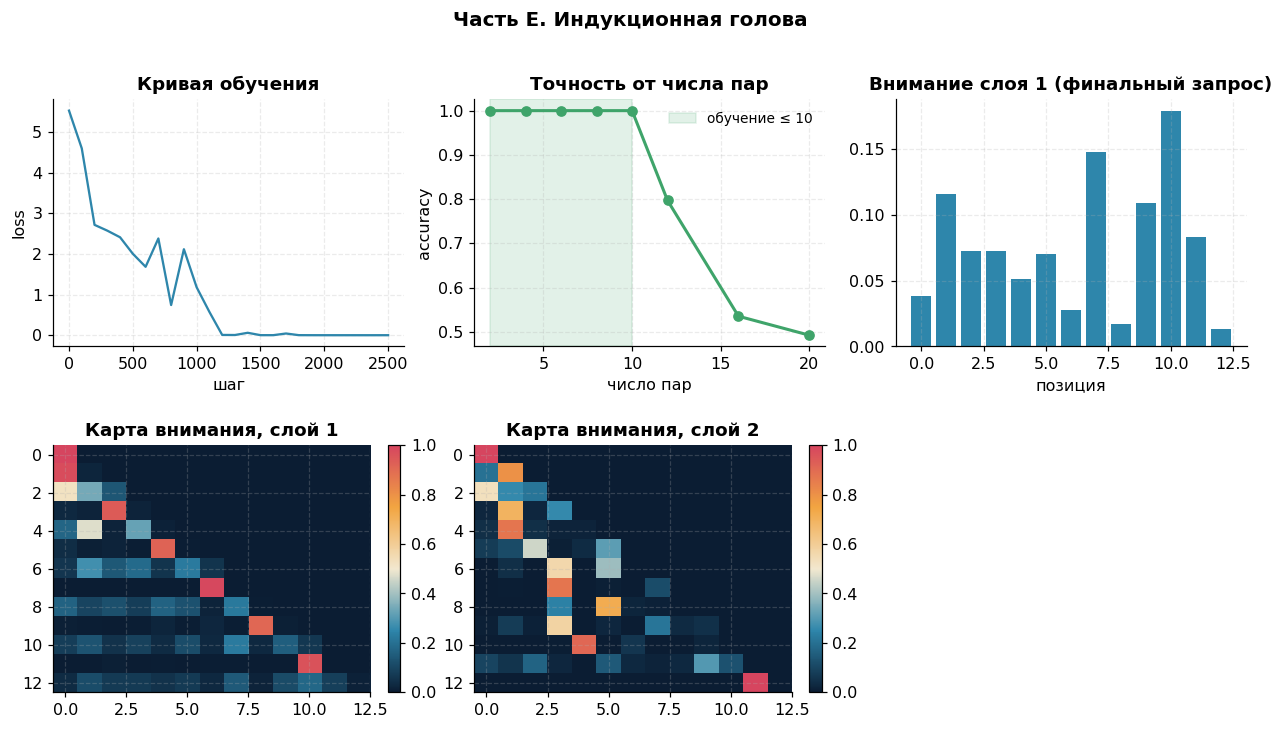

In [21]:
# TODO E.3: рисунок E: кривая обучения, точность от числа пар (отметьте диапазон обучения),
# карты внимания слоёв 1 и 2 для одного примера и столбчатая диаграмма внимания финального запроса.
# Подсказка: x_ex, y_ex, qi_ex = make_recall_batch(1, 6, torch.Generator().manual_seed(123))
# и logits_ex, maps = model(x_ex, ret=True)
x_ex, y_ex, qi_ex = make_recall_batch(1, 6, torch.Generator().manual_seed(SEED))
with torch.no_grad():
    logits_ex, maps = model(x_ex, ret=True)

fig = plt.figure(figsize=(14, 7))
gs = fig.add_gridspec(2, 3, hspace=0.4)

ax1 = fig.add_subplot(gs[0, 0])
ax1.plot([c[0] for c in curve], [c[1] for c in curve], color=PALETTE["attn"])
ax1.set_xlabel("шаг"); ax1.set_ylabel("loss"); ax1.set_title("Кривая обучения")

ax2 = fig.add_subplot(gs[0, 1])
ax2.plot(NS, acc, "o-", color=PALETTE["good"], linewidth=2)
ax2.axvspan(2, N_MAX, color=PALETTE["good"], alpha=0.15, label=f"обучение ≤ {N_MAX}")
ax2.set_xlabel("число пар"); ax2.set_ylabel("accuracy")
ax2.set_title("Точность от числа пар"); ax2.legend(fontsize=9)

ax3 = fig.add_subplot(gs[0, 2])
ax3.bar(range(x_ex.shape[1]), maps[0][0, -1].numpy(), color=PALETTE["attn"])
ax3.set_xlabel("позиция"); ax3.set_title("Внимание слоя 1 (финальный запрос)")

ax4 = fig.add_subplot(gs[1, 0])
im1 = ax4.imshow(maps[0][0].numpy(), cmap=CMAP_HEAT, aspect="auto")
ax4.set_title("Карта внимания, слой 1"); plt.colorbar(im1, ax=ax4, fraction=0.046)

ax5 = fig.add_subplot(gs[1, 1])
im2 = ax5.imshow(maps[1][0].numpy(), cmap=CMAP_HEAT, aspect="auto")
ax5.set_title("Карта внимания, слой 2"); plt.colorbar(im2, ax=ax5, fraction=0.046)
finish(fig, "Часть E. Индукционная голова")

**Вопрос E.** Почему для этой задачи недостаточно одного слоя внимания? Опишите, какую информацию
переносит первый слой и что именно сравнивает второй.

**Ответ E.**   
Одного слоя внимания недостаточно, потому что индукционная схема — это двухшаговая композиция: первый слой в позиции k_i (ключа) должен записать информацию о следующем токене v_i; второй слой сравнивает финальный запрос k_i с ключами всех позиций и извлекает записанное значение. Один слой внимания выполняет только одну операцию — найти похожее и усреднить, у него нет промежуточного хранилища, чтобы запомнить значение к ключу. Первый слой переносит информацию через позицию, второй — извлекает её по совпадению ключей.

## Часть F. Линейное внимание: состояние вместо матрицы внимания

Если заменить $\exp(q^\top k)$ на $\varphi(q)^\top \varphi(k)$ с неотрицательным $\varphi$, сумму
можно переставить и получить рекуррентную форму с состоянием фиксированного размера:

$
S_t = S_{t-1} + \varphi(k_t) v_t^{\top}, \qquad
o_t = \frac{\varphi(q_t)^{\top} S_t}{\varphi(q_t)^{\top} z_t}, \qquad z_t = z_{t-1} + \varphi(k_t).
$

Генерация становится $O(1)$ по памяти, но состояние размера $d \times d$ — это фиксированная
ёмкость, в которую нужно уложить весь контекст.

**Задание F.1.** Реализуйте параллельную и рекуррентную формы линейного внимания и проверьте, что
они дают один результат.
**Задание F.2.** Измерьте ёмкость состояния: сложите в $S$ ровно $N$ пар «ключ–значение» и оцените
качество чтения (косинусная близость к истинному значению) при росте $N$.
**Задание F.3.** Постройте рисунок: рост KV-кэша softmax-внимания против постоянного состояния
линейного внимания и кривую качества чтения от числа сохранённых пар.

In [22]:
def phi(x):
    return torch.nn.functional.elu(x) + 1          # неотрицательное отображение признаков

def linear_attention_parallel(Q, K, V):
    # TODO F.1a: параллельная форма: для каждой позиции t числитель = sum_{s<=t} phi(k_s) (phi(q_t).phi(k_s)) v_s
    #            удобная реализация: S_t = cumsum(phi(k) v^T), z_t = cumsum(phi(k)),
    #            затем o_t = phi(q_t) S_t / (phi(q_t) . z_t)
    phi_Q, phi_K = phi(Q), phi(K)
    KV = phi_K.unsqueeze(-1) * V.unsqueeze(1)
    S = KV.cumsum(dim=0)
    z = phi_K.cumsum(dim=0)
    num = torch.einsum("td,tdk->tk", phi_Q, S)
    den = torch.einsum("td,td->t", phi_Q, z) + 1e-9
    return num / den.unsqueeze(-1)

def linear_attention_recurrent(Q, K, V):
    # TODO F.1b: явный цикл по времени с состоянием S (d x d) и вектором z (d)
    T, d = Q.shape
    S = torch.zeros(d, d); z = torch.zeros(d)
    outs = []
    for t in range(T):
        pk, pq = phi(K[t]), phi(Q[t])
        S = S + torch.outer(pk, V[t]); z = z + pk
        outs.append((pq @ S) / (pq @ z + 1e-9))
    return torch.stack(outs)

torch.manual_seed(SEED)
T_l, d_l = 40, 16
Ql, Kl, Vl = torch.randn(T_l, d_l), torch.randn(T_l, d_l), torch.randn(T_l, d_l)
# TODO F.1c: сравните две формы и напечатайте максимальное расхождение и размер состояния
out_p = linear_attention_parallel(Ql, Kl, Vl)
out_r = linear_attention_recurrent(Ql, Kl, Vl)
print(f"расхождение: {(out_p - out_r).abs().max().item():.2e}")
print(f"размер состояния: {d_l * d_l} чисел")

расхождение: 1.19e-07
размер состояния: 256 чисел


In [24]:
# TODO F.2: ёмкость состояния
# для каждого N из NS_CAP: возьмите N случайных ключей и значений размерности d_l,
# сложите состояние S = sum phi(k_i) v_i^T, z = sum phi(k_i),
# прочитайте значение по каждому ключу и усредните косинусную близость с истинным значением
NS_CAP = [1, 2, 4, 8, 16, 32, 64, 128, 256]
quality = []
torch.manual_seed(SEED)
for N in NS_CAP:
    Kc = torch.randn(N, d_l); Vc = torch.randn(N, d_l)
    S = sum(torch.outer(phi(Kc[i]), Vc[i]) for i in range(N))
    z = sum(phi(Kc[i]) for i in range(N))
    cos = []
    for i in range(N):
        pred = (phi(Kc[i]) @ S) / (phi(Kc[i]) @ z + 1e-9)
        c = F.cosine_similarity(pred.unsqueeze(0), Vc[i].unsqueeze(0)).item()
        cos.append(c)
    quality.append(float(np.mean(cos)))

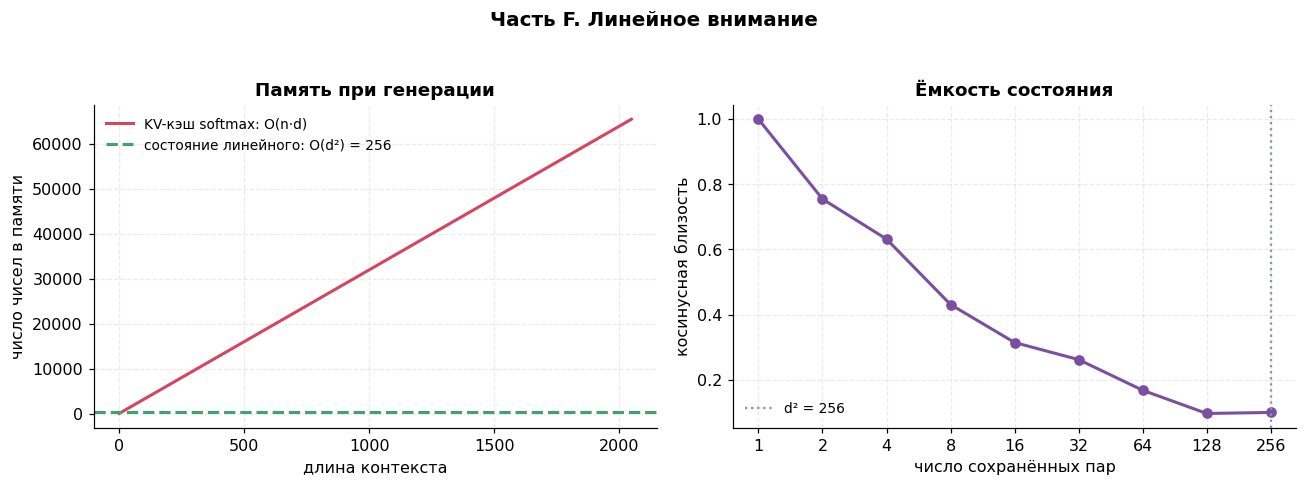

In [25]:
# TODO F.3: рисунок F: слева память при генерации (KV-кэш O(n) против состояния O(1)),
# справа качество чтения из состояния от числа сохранённых пар (с отметкой d_l x d_l)
fig, axes = plt.subplots(1, 2, figsize=(12, 4.4))
n_tok = np.arange(1, 2049)
axes[0].plot(n_tok, n_tok * d_l * 2, color=PALETTE["bad"], linewidth=2, label="KV-кэш softmax: O(n·d)")
axes[0].axhline(d_l * d_l, color=PALETTE["good"], linewidth=2, linestyle="--",
                label=f"состояние линейного: O(d²) = {d_l * d_l}")
axes[0].set_xlabel("длина контекста"); axes[0].set_ylabel("число чисел в памяти")
axes[0].set_title("Память при генерации"); axes[0].legend(fontsize=9)

axes[1].plot(NS_CAP, quality, "o-", color=PALETTE["accent"], linewidth=2)
axes[1].axvline(d_l * d_l, color=PALETTE["gray"], linestyle=":", label=f"d² = {d_l * d_l}")
axes[1].set_xscale("log", base=2); axes[1].set_xticks(NS_CAP); axes[1].set_xticklabels(NS_CAP)
axes[1].set_xlabel("число сохранённых пар"); axes[1].set_ylabel("косинусная близость")
axes[1].set_title("Ёмкость состояния"); axes[1].legend(fontsize=9)
finish(fig, "Часть F. Линейное внимание")

**Вопрос F.** Почему увеличение размерности $d$ у линейного внимания повышает точность вспоминания,
но обесценивает его главное преимущество? Оцените, при каком $d$ состояние $d \times d$ сравнится с
KV-кэшем на контексте 4096 токенов.

**Ответ F.**  
Рост d повышает точность, потому что ёмкость состояния d x d растёт как d^2 и может вместить больше независимых пар ключ–значение. Но при этом стоимость памяти на один токен растёт как d^2, а не как O(1) — теряется главное преимущество линейного внимания. Состояние размера d^2 сравнится с KV-кэшем на контексте n токенов при d^2 = 2·n·d, то есть d = 2n. Для n = 4096 критическое d = 8192.

## Часть G. Избирательная рекуррентность

Если сделать затухание и запись зависящими от входа

$
h_t = a(x_t) \odot h_{t-1} + b(x_t) \odot u(x_t),
$

то модель получает управляемую память: она может удерживать нужное и игнорировать шум. Это ядро
идеи моделей пространства состояний с избирательностью (Mamba).

Задача: в последовательности длины 64 встречается маркер `FLAG`; нужно назвать символ,
стоящий сразу после него. Всё остальное — шум.

**Задание G.1.** Реализуйте два варианта ячейки: с гейтами, зависящими от входа, и с обучаемым, но
постоянным затуханием.
**Задание G.2.** Обучите оба варианта и сравните точность.
**Задание G.3.** Постройте профили гейтов по позициям и оцените долю каналов, у которых гейт
сохранения превышает 0.9.

In [26]:
VOC_S, FLAG, T_S = 20, 19, 64

def flag_batch(bs, gen):
    x = torch.randint(0, 16, (bs, T_S), generator=gen)
    pos = torch.randint(2, T_S - 2, (bs,), generator=gen)
    tgt = torch.randint(0, 16, (bs,), generator=gen)
    x[torch.arange(bs), pos] = FLAG
    x[torch.arange(bs), pos + 1] = tgt
    return x, tgt, pos

class RecurCell(nn.Module):
    def __init__(self, d=48, selective=True):
        super().__init__()
        self.selective = selective
        self.emb = nn.Embedding(VOC_S, d)
        self.inp = nn.Linear(2 * d, d)                 # локальное окно ширины 2 (аналог conv1d)
        if selective:
            self.ga = nn.Linear(2 * d, d); self.gb = nn.Linear(2 * d, d)
        else:
            self.logit_a = nn.Parameter(torch.zeros(d))
        self.head = nn.Sequential(nn.LayerNorm(d), nn.Linear(d, VOC_S))

    def forward(self, x, return_gates=False):
        e = self.emb(x); B, Tn, d = e.shape
        e_prev = torch.cat([torch.zeros(B, 1, d), e[:, :-1]], 1)
        ctx = torch.cat([e, e_prev], -1)
        u = self.inp(ctx)
        # TODO G.1: получите гейты
        #   selective=True:  a = sigmoid(self.ga(ctx)), b = sigmoid(self.gb(ctx))
        #   selective=False: a = sigmoid(self.logit_a) для всех позиций, b = единицы
        # затем прогоните рекуррентность h = a[:, t] * h + b[:, t] * u[:, t]
        # и верните self.head(h), а при return_gates=True — ещё и (a, b)
        if self.selective:
            a = torch.sigmoid(self.ga(ctx))
            b = torch.sigmoid(self.gb(ctx))
        else:
            a = torch.sigmoid(self.logit_a).view(1, 1, d).expand(B, Tn, d)
            b = torch.ones(B, Tn, d)
        h = torch.zeros(B, d)
        outs = []
        for t in range(Tn):
            h = a[:, t] * h + b[:, t] * u[:, t]
            outs.append(h)
        h_seq = torch.stack(outs, dim=1)
        logits = self.head(h_seq)
        return (logits, (a, b)) if return_gates else logits

In [32]:
# TODO G.2: обучите обе ячейки и сравните точность
def train_cell(selective, steps=600, bs=64, lr=5e-3, seed=0):
    gen = torch.Generator().manual_seed(seed)
    m = RecurCell(d=D_CELL, selective=selective)
    opt = torch.optim.AdamW(m.parameters(), lr=lr)
    curve = []
    for s in range(steps):
        x, y, pos = flag_batch(bs, gen)
        logits = m(x)
        # предсказываем на последней позиции — модель видит весь контекст
        sel_logits = logits[:, -1, :]
        loss = F.cross_entropy(sel_logits, y)
        opt.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(m.parameters(), 1.0)
        opt.step()
        if s % 25 == 0:
            m.eval()
            with torch.no_grad():
                xv, yv, pv = flag_batch(256, gen)
                lv = m(xv)
                acc = (lv[:, -1, :].argmax(-1) == yv).float().mean().item()
            m.train()
            curve.append((s, acc))
    return m, curve, gen

t0 = time.time()
cell_sel, curve_sel, gen_sel = train_cell(True, seed=SEED)
cell_fix, curve_fix, gen_fix = train_cell(False, seed=SEED)
print("избирательная ячейка: точность %.3f" % curve_sel[-1][1])
print("фиксированное затухание: точность %.3f (угадывание %.3f)" % (curve_fix[-1][1], 1 / 16))
print("обучение заняло %.0f c" % (time.time() - t0))

избирательная ячейка: точность 1.000
фиксированное затухание: точность 0.074 (угадывание 0.062)
обучение заняло 109 c


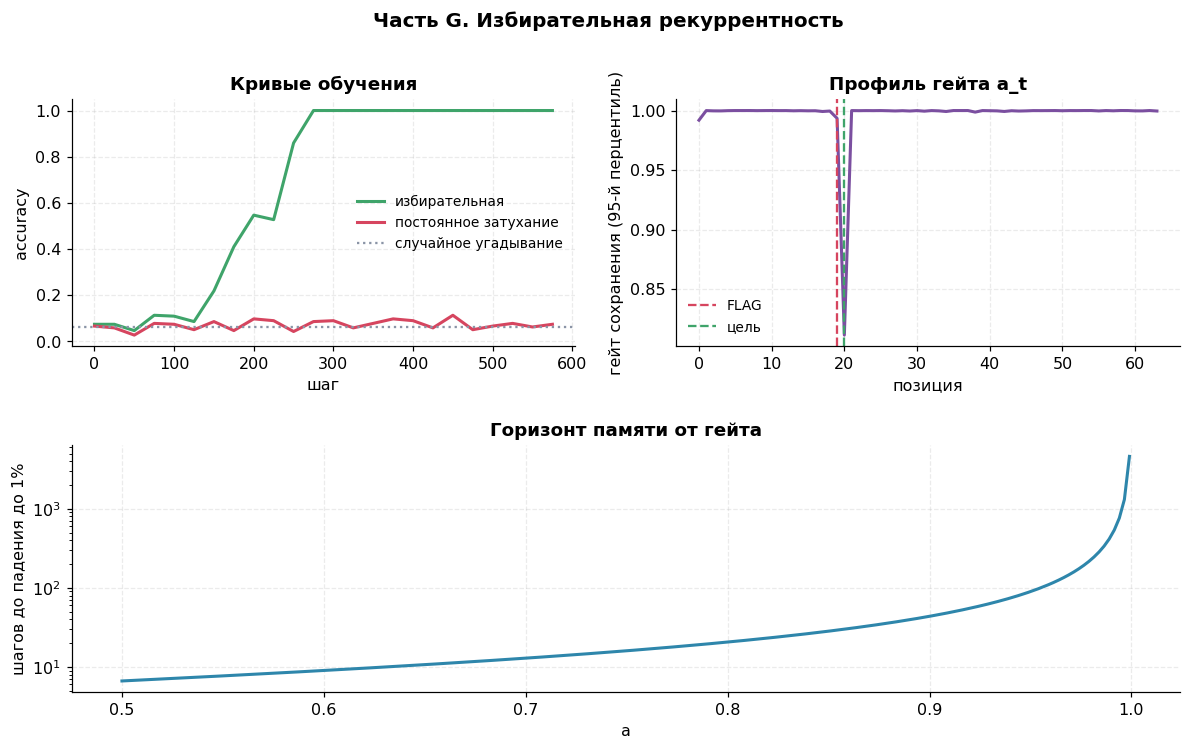

доля каналов с гейтом > 0.9: 0.146


In [33]:
# TODO G.3: рисунок G: кривые обучения обеих ячеек; профили гейтов (95-й перцентиль по каналам)
# с отметками позиции маркера и целевого символа; горизонт памяти log(0.01)/log(a) от a.
# Подсказка: xs, ys, pos = flag_batch(1, torch.Generator().manual_seed(77))
#            _, (a_g, b_g) = cell_sel(xs, return_gates=True)
xs, ys, pos = flag_batch(1, torch.Generator().manual_seed(77))
with torch.no_grad():
    _, (a_g, b_g) = cell_sel(xs, return_gates=True)
a_g = a_g[0].numpy()

fig = plt.figure(figsize=(13, 7))
gs = fig.add_gridspec(2, 2, hspace=0.4)

ax1 = fig.add_subplot(gs[0, 0])
ax1.plot([c[0] for c in curve_sel], [c[1] for c in curve_sel],
         color=PALETTE["good"], linewidth=2, label="избирательная")
ax1.plot([c[0] for c in curve_fix], [c[1] for c in curve_fix],
         color=PALETTE["bad"], linewidth=2, label="постоянное затухание")
ax1.axhline(1 / 16, ls=":", color=PALETTE["gray"], label="случайное угадывание")
ax1.set_xlabel("шаг"); ax1.set_ylabel("accuracy"); ax1.set_title("Кривые обучения")
ax1.legend(fontsize=9)

ax2 = fig.add_subplot(gs[0, 1])
p95 = np.percentile(a_g, 95, axis=-1)
ax2.plot(p95, color=PALETTE["accent"], linewidth=2)
ax2.axvline(int(pos[0]), color=PALETTE["bad"], linestyle="--", label="FLAG")
ax2.axvline(int(pos[0]) + 1, color=PALETTE["good"], linestyle="--", label="цель")
ax2.set_xlabel("позиция"); ax2.set_ylabel("гейт сохранения (95-й перцентиль)")
ax2.set_title("Профиль гейта a_t"); ax2.legend(fontsize=9)

ax3 = fig.add_subplot(gs[1, :])
a_vals = np.linspace(0.5, 0.999, 200)
horizon_vals = np.where(a_vals < 1, np.log(0.01) / np.log(a_vals), np.nan)
ax3.plot(a_vals, horizon_vals, color=PALETTE["attn"], linewidth=2)
ax3.set_yscale("log"); ax3.set_xlabel("a"); ax3.set_ylabel("шагов до падения до 1%")
ax3.set_title("Горизонт памяти от гейта")
finish(fig, "Часть G. Избирательная рекуррентность")

frac_high = float((a_g > 0.9).mean())
print(f"доля каналов с гейтом > 0.9: {frac_high:.3f}")

**Вопрос G.** Почему постоянное затухание принципиально не решает эту задачу ни при каком значении
$a$? Рассмотрите два предельных случая: $a \to 1$ и $a \ll 1$.

**Ответ G.**   
Постоянное затухание означает, что гейт a один и тот же для всех позиций и всех каналов. У модели нет способа отличить значимый токен tgt от шумовых токенов — и то, и другое проходит через одну и ту же арифметику.  
Случай a → 1 (долгая память без отбора).
Состояние почти не забывает: h_t = h_{t-1} + u_t. К моменту выдачи ответа в h_T накоплена сумма вкладов от всех позиций. Информация о tgt там есть, но она — одно слагаемое из $n$, то есть порядка 1/$n$ от полного состояния.  
Случай a ≪ 1 (быстрое забывание).
Гейт быстро гасит состояние: вклад от tgt, записанного на позиции pos + 1, к моменту финального токена (через 30–40 шагов) умножается на a^(T - pos - 1). Уже при a = 0.9 и разнице в 30 шагов это 0.9^30 ≈ 0.04, а при a = 0.7 — 0.7^30 ≈ 2·10⁻⁵. Информация о tgt просто не доживает до точки чтения.

## Часть H. Декодирование, статистика попыток и мост к следующей теме

Модель задаёт распределение, а текст получается процедурой выборки. Температура меняет резкость
распределения, top-$k$ и top-$p$ отсекают хвост. Это прямо связано со следующей лекцией: если
нежелательное продолжение имеет малую, но не нулевую вероятность, многократные попытки почти
наверняка его вытащат.

**Задание H.1.** Реализуйте softmax с температурой, top-$k$ и top-$p$ отсечение.
**Задание H.2.** Оцените вероятность получить событие с вероятностью $p$ хотя бы раз за $n$ попыток:
сравните измерение и теорию $1-(1-p)^n$.
**Задание H.3.** Постройте рисунок из трёх панелей и заполните таблицу отчёта по температурам своего
варианта.
**Задание H.4.** Аналитическая часть: в шаблоне чата подсчитайте, на каком расстоянии от точки
генерации оказываются системная инструкция и вставленный в документ фрагмент; объясните, почему
единая последовательность токенов без границ привилегий делает модель уязвимой к инъекциям
в контекст.

In [34]:
V_dec = 40
rank = np.arange(1, V_dec + 1)
logits = np.log(1.0 / rank ** 1.1)
logits = logits - logits.max()

def softmax_t(z, tau):
    # TODO H.1a: softmax с температурой, устойчиво к переполнению
    z = z / tau
    z = z - z.max()
    e = np.exp(z)
    return e / e.sum()

def top_k_filter(p, k):
    # TODO H.1b: оставьте k самых вероятных токенов и перенормируйте
    idx = np.argsort(p)[::-1][:k]
    out = np.zeros_like(p); out[idx] = p[idx]
    return out / out.sum()

def top_p_filter(p, thr):
    # TODO H.1c: оставьте минимальный набор токенов с суммарной вероятностью >= thr
    idx = np.argsort(p)[::-1]
    cum = np.cumsum(p[idx])
    keep_n = int(np.searchsorted(cum, thr)) + 1
    keep = idx[:keep_n]
    out = np.zeros_like(p); out[keep] = p[keep]
    return out / out.sum()

def entropy(p):
    return float(-(p * np.log(p + 1e-12)).sum())

In [35]:
# TODO H.2: статистика многих попыток
# для p_rare в [0.001, 0.005, 0.02] и n от 20 до 360 оцените по 60 повторам частоту события
# «редкий токен выпал хотя бы раз» и сравните с теорией 1-(1-p)^n
p_rare_vals = [0.001, 0.005, 0.02]
n_vals = np.arange(20, 361, 20)
gen_h = np.random.default_rng(SEED)

theory_curves = {}
measured_curves = {}
for p_rare in p_rare_vals:
    theory_curves[p_rare] = 1 - (1 - p_rare) ** n_vals
    measured_curves[p_rare] = [
        (gen_h.random((60, n)) < p_rare).any(axis=1).mean() for n in n_vals
    ]

for p_rare in p_rare_vals:
    err = np.abs(measured_curves[p_rare] - theory_curves[p_rare]).max()
    print(f"p = {p_rare}: макс. отклонение от теории = {err:.3f}")

p = 0.001: макс. отклонение от теории = 0.088
p = 0.005: макс. отклонение от теории = 0.102
p = 0.02: макс. отклонение от теории = 0.096


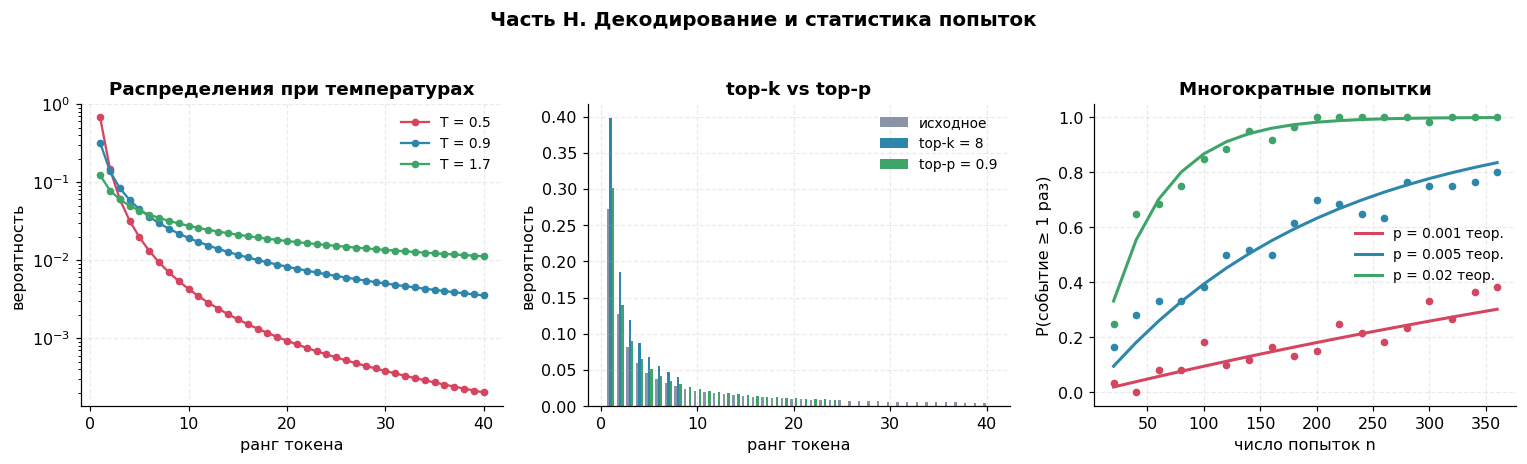

In [36]:
# TODO H.3: рисунок H: (1) распределения при температурах TAUS в логарифмической шкале,
# (2) сравнение исходного распределения с top-k и top-p, (3) вероятность события хотя бы раз
# за n попыток: теория линиями, измерение точками
fig, axes = plt.subplots(1, 3, figsize=(14, 4.2))

for T, color in zip(TAUS, [PALETTE["bad"], PALETTE["attn"], PALETTE["good"]]):
    axes[0].semilogy(rank, softmax_t(logits, T), "o-", color=color,
                     markersize=4, label=f"T = {T}")
axes[0].set_xlabel("ранг токена")
axes[0].set_ylabel("вероятность")
axes[0].set_title("Распределения при температурах")
axes[0].legend(fontsize=9)

p0 = softmax_t(logits, 1.0)
pk = top_k_filter(p0, 8)
pp = top_p_filter(p0, 0.9)
axes[1].bar(rank - 0.25, p0, width=0.25, color=PALETTE["gray"], label="исходное")
axes[1].bar(rank, pk, width=0.25, color=PALETTE["attn"], label="top-k = 8")
axes[1].bar(rank + 0.25, pp, width=0.25, color=PALETTE["good"], label="top-p = 0.9")
axes[1].set_xlabel("ранг токена")
axes[1].set_ylabel("вероятность")
axes[1].set_title("top-k vs top-p")
axes[1].legend(fontsize=9)

for p_rare, color in zip(p_rare_vals, [PALETTE["bad"], PALETTE["attn"], PALETTE["good"]]):
    axes[2].plot(n_vals, theory_curves[p_rare], color=color, linewidth=2,
                 label=f"p = {p_rare} теор.")
    axes[2].plot(n_vals, measured_curves[p_rare], "o", color=color, markersize=4)
axes[2].set_xlabel("число попыток n")
axes[2].set_ylabel("P(событие ≥ 1 раз)")
axes[2].set_title("Многократные попытки")
axes[2].legend(fontsize=9)

finish(fig, "Часть H. Декодирование и статистика попыток")

спец           среднее расстояние до точки генерации: 14.2
система        среднее расстояние до точки генерации: 22.0
пользователь   среднее расстояние до точки генерации: 15.0
документ       среднее расстояние до точки генерации: 9.5
инъекция       среднее расстояние до точки генерации: 4.5


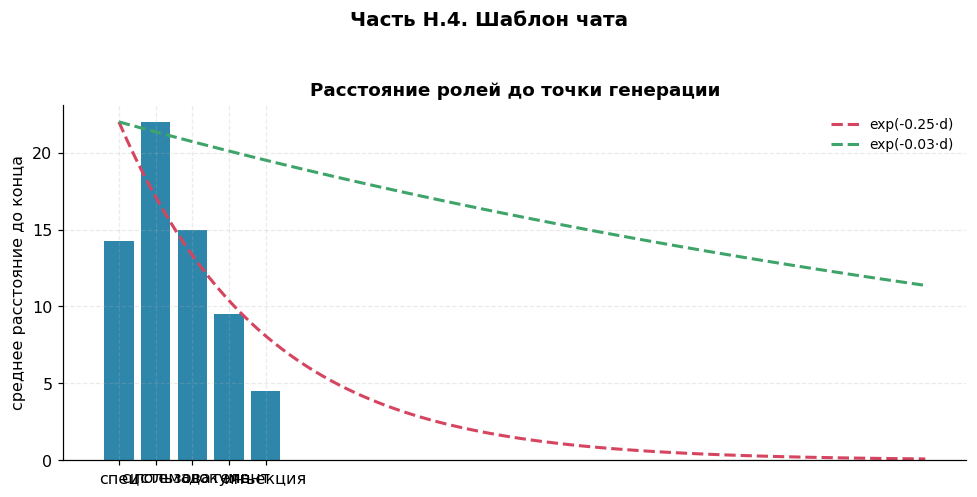

длина шаблона: 26 токенов


In [37]:
# TODO H.4: расстояния в шаблоне чата
# шаблон задан ниже как список (роль, число токенов); точка генерации — конец последовательности
TEMPLATE = [("спец", 1), ("система", 7), ("спец", 1), ("пользователь", 5),
            ("спец", 1), ("документ", 4), ("инъекция", 6), ("спец", 1)]
# TODO H.4a: посчитайте среднее расстояние от позиции каждой роли до конца последовательности
# TODO H.4b: постройте столбчатую диаграмму «роль — среднее расстояние до точки генерации»
#            и добавьте кривые относительного веса внимания exp(-m*d) для m = 0.25 и 0.03
pos = 0
distances = {}
for role, n in TEMPLATE:
    mid = pos + (n - 1) / 2
    distances.setdefault(role, []).append(mid)
    pos += n
total = pos

means = {role: total - np.mean(v) for role, v in distances.items()}
for role, d in means.items():
    print(f"{role:<14} среднее расстояние до точки генерации: {d:.1f}")

fig, ax = plt.subplots(figsize=(9, 4.5))
roles = list(means.keys())
vals = [means[r] for r in roles]
ax.bar(roles, vals, color=PALETTE["attn"])
d_grid = np.linspace(0, max(vals), 100)
for m, color in [(0.25, PALETTE["bad"]), (0.03, PALETTE["good"])]:
    ax.plot(d_grid, np.exp(-m * d_grid) * max(vals), "--", color=color,
            linewidth=2, label=f"exp(-{m}·d)")
ax.set_ylabel("среднее расстояние до конца")
ax.set_title("Расстояние ролей до точки генерации")
ax.legend(fontsize=9)
finish(fig, "Часть H.4. Шаблон чата")
print(f"длина шаблона: {total} токенов")

**Вопрос H.** Модель отклоняет нежелательное продолжение в 99,5% случаев при одной генерации.
Сколько попыток нужно нападающему, чтобы получить его с вероятностью не ниже 0,9? Какой вывод это
даёт для методики оценки устойчивости?

**Ответ H.**  
P = 1 - q^n = 1 - 0.995^n   
0.995^n ≤ 0.1  
n ≥ log(0.1) / log(0.995) ≈ 2.30 / 0.00501 ≈ 459 попыток  
Единичный факт отказа ничего не говорит о реальной устойчивости системы. Если генератор стохастичен (а он всегда стохастичен из-за sampling — температуры, top-k, top-p), защита «сработала 1 раз» означает лишь, что в этот раз мы попали в благоприятную ветку распределения. Следующая попытка с той же вероятностью 1 - q даст нежелательный выход.

## Отчёт

### Таблица 1. Токенизация (часть A)

| Показатель | Значение |
|---|---|
| Число выполненных слияний | 120|
| Размер словаря токенов | 92|
| Сжатие «символы → BPE» | 2,3|
| Отношение «BPE → слова» | 3,49|
| Доля редких токенов (частота ≤ `RARE_THR`) |48,9% |

### Таблица 2. Затухание градиента (часть B)

| $\rho(W)$ или $f_t$ | Норма при $k=100$ | Горизонт до $10^{-6}$ |
|---|---|---|
| 0.9 | 2,7e-5| 132|
| 1.0 | 1| - |
| 1.2 | 8e7| - |
| $f_t = 0.99$ | 0.37| 1375|

### Таблица 3. Масштабирование внимания (часть C)

| $d_k$ | Энтропия с делителем | Энтропия без делителя |
|---|---|---|
| 8 | 3.6| 0.1|
| 64 | 3.6| 0.0|
| 256 | 3.6| 0.0|

### Таблица 4. Мини-трансформер (часть E)

| Число пар в контексте | 2 | 4 | 8 | 12 | 16 | 20 |
|---|---|---|---|---|---|---|
| Точность вспоминания | 1| 1| 1| 0.797| 0.535| 0.492|

Время обучения: 100 с

### Таблица 5. Линейное внимание (часть F)

| Показатель | Значение |
|---|---|
| Расхождение параллельной и рекуррентной форм | 1.2e-7|
| Размер состояния, чисел | 256|
| Качество чтения при 4 парах | 0.65|
| Качество чтения при 256 парах | 0.09|

### Таблица 6. Избирательная рекуррентность (часть G)

| Вариант ячейки | Точность | Комментарий |
|---|---|---|
| избирательные гейты | 1| |
| постоянное затухание | 0.074| |
| случайное угадывание | 0.062 | теоретическое значение |

Доля каналов с гейтом сохранения выше 0.9: 0.146

### Таблица 7. Декодирование (часть H)

| Температура варианта | Энтропия, нат | $p_{\max}$ |
|---|---|---|
| 0.5| 1.27| 0.675|
| 0.9|2.69| 0.321|
| 1.7| 3.45| 0.122|

Число попыток для события с $p=0{,}005$ до вероятности 0,9: 459

### Выводы

Сформулируйте не менее пяти выводов. Каждый вывод должен опираться на конкретное измеренное число
из вашего прогона.

1. BPE-токенизация дала сжатие 2.30× относительно посимвольного представления: 2652 символа → 1152 BPE-токена  
2. Затухание градиента подтверждает проблему обычной рекуррентности. При
ρ=0.9 норма произведения падает до 10−6 примерно за 132 шага, при ρ=1.0 не затухает, а при ρ=1.2 взрывается.
3. Масштабирование внимания критично. Без делителя sqrt(d_k) энтропия внимания практически равна нулю: softmax вырождается в one-hot, градиенты по ключам обнуляются.
4. Мини-трансформер показывает резкое падение обобщения за пределы обучающих длин. На длинах до 10 пар, которые были в обучении, точность 1.000. На 12 парах она падает до 0.797, на 16 — до 0.535, на 20 — до 0.492. Это прямое измерение ограничения экстраполяции по длине контекста.
5. Избирательная рекуррентность решает задачу, а постоянное затухание — нет. Избирательная ячейка достигла точности 1.000, фиксированное затухание — только 0.074 при случайном угадывании 0.062. Доля каналов с гейтом > 0.9 составила 14.6%, то есть модель научилась удерживать информацию лишь в части каналов.

## Контрольные вопросы

1. Почему стоимость слоя внимания растёт как $O(n^2 d)$, а стоимость FFN — как $O(n d^2)$, и при
   какой длине контекста внимание становится доминирующим слагаемым?

   Внимание строит матрицу $n$ x $n$ затем умножает её на V, что дает нам $O(n^2 d)$.  
   FFN обрабатывает каждый токен независимо: две матрицы $d$ x $4d$ и $4d$ x $d$ дают нам $O(nd^2 )$.  Внимание становится доминирующим при $n^2 d > nd^2$  
2. Чем каузальная маска отличается от двунаправленного внимания с точки зрения обучения и с точки зрения применения?  
Каузальная маска запрещает токену смотреть на будущие позиции. Это нужно для авторегрессионного обучения и генерации. Двунаправленное внимание видит весь контекст сразу, оно лучше для задач понимания, но напрямую не подходит для генерации слева направо.  
3. Почему RoPE позволяет расширять контекст после обучения, а обучаемая абсолютная кодировка — нет?  
RoPE зависит от разности позиций $t - s$, а не от абсолютных номеров. Поэтому его можно вычислять для новых позиций после обучения. Обучаемая абсолютная кодировка имеет параметры только для позиций из обучающего диапазона; за его пределами значения не определены и не имеют смысла.  
4. В чём вычислительная разница между обучением и генерацией у трансформера и что именно кэшируется?  
При обучении все позиции обрабатываются параллельно, строится полная матрица внимания. При генерации токены появляются по одному. Чтобы не пересчитывать прошлое, кэшируются ключи и значения $K,V$ предыдущих токенов — это KV-кэш.
5. Как GQA и MQA уменьшают KV-кэш и чем за это приходится платить?  
В GQA/MQA несколько голов запросов делят одни и те же головы ключей и значений. Это уменьшает число $K,V$, которые нужно хранить, и снижает нагрузку на память. Плата — меньшая выразительность внимания, возможное падение качества.
6. Почему линейное внимание проигрывает softmax-вниманию на задачах точного вспоминания?   
Линейное внимание сжимает всю историю в состояние фиксированного размера
$d$ x $d$. Оно не может точно указать на одну конкретную позицию, как softmax-внимание, которое хранит полную матрицу $n$ x $n$. Поэтому при росте числа пар качество чтения падает.
7. Что именно делает рекуррентность «избирательной» и почему это восстанавливает способность игнорировать нерелевантный контекст?  
Гейты зависят от входа. Модель может научиться сохранять важные токены и сбрасывать/игнорировать шум. Постоянное затухание так не умеет: оно применяет одну и ту же арифметику ко всем токенам.  
8. Почему смесь экспертов требует балансирующей потери и что происходит без неё?  
Без неё роутер может отправлять почти все токены нескольким экспертам. Остальные эксперты не обучаются, ёмкость модели используется плохо. Балансирующая потеря заставляет распределять нагрузку между экспертами.
9. Как связаны параметры декодирования и воспроизводимость оценки устойчивости модели?  
Температура, top-k и top-p управляют случайностью. Если их не фиксировать, результат одной генерации не воспроизводится. Для оценки устойчивости нужно фиксировать seed и параметры декодирования, а также делать много попыток, иначе выводы статистически недостоверны.
10. Почему шаблон чата не создаёт настоящей границы привилегий между системной инструкцией и содержимым документа?  
Шаблон — это просто последовательность токенов со специальными маркерами. Для модели системная инструкция и текст документа — одинаковые токены контекста. Если в документе есть конфликтующая инструкция, модель может следовать ей из-за близости к точке генерации и весов внимания. В части H видно, что инъекция находится в среднем на расстоянии 4.5 токена от конца, а системная инструкция — на 22.0, то есть инъекция ближе и может получать больше внимания.

## Дополнительные задания

- Добавьте в часть E третий слой и проверьте, меняется ли характер переноса на длины больше
  обучающих.
- Замените в части E обучаемую абсолютную кодировку на RoPE и повторите измерение точности для
  16 и 20 пар.
- Реализуйте в части F многоголовое линейное внимание и постройте зависимость качества чтения от
  числа голов при фиксированном общем размере состояния.
- Реализуйте слой смеси экспертов с балансирующей потерей и покажите, как меняется распределение
  нагрузки при её отключении.
- Постройте в части H оценку числа попыток до заданной вероятности успеха как функцию $p$ и
  обсудите, как это влияет на протокол тестирования.

## Чек-лист сдачи

- [ ] Заполнен паспорт работы, указан вариант и его параметры.
- [ ] Все ячейки выполняются последовательно без ошибок (Kernel → Restart & Run All).
- [ ] Реализованы все `TODO` в частях A–H.
- [ ] Заполнены таблицы 1–7 числами своего варианта.
- [ ] Даны ответы на вопросы A–H и контрольные вопросы 1–10.
- [ ] Сформулировано не менее пяти выводов со ссылками на измеренные значения.
- [ ] Все графики подписаны по-русски и читаемы.



## Литература

- Vaswani A. et al. Attention Is All You Need (2017): <https://arxiv.org/abs/1706.03762>
- Hochreiter S., Schmidhuber J. Long Short-Term Memory (1997):
  <https://direct.mit.edu/neco/article/9/8/1735/6109>
- Su J. et al. RoFormer: Enhanced Transformer with Rotary Position Embedding (2021):
  <https://arxiv.org/abs/2104.09864>
- Press O. et al. Train Short, Test Long: Attention with Linear Biases (ALiBi) (2021):
  <https://arxiv.org/abs/2108.12409>
- Katharopoulos A. et al. Transformers are RNNs: Fast Autoregressive Transformers with Linear
  Attention (2020): <https://arxiv.org/abs/2006.16236>
- Gu A., Dao T. Mamba: Linear-Time Sequence Modeling with Selective State Spaces (2023):
  <https://arxiv.org/abs/2312.00752>
- Ainslie J. et al. GQA: Training Generalized Multi-Query Transformer Checkpoints (2023):
  <https://arxiv.org/abs/2305.13245>
- Dao T. et al. FlashAttention: Fast and Memory-Efficient Exact Attention with IO-Awareness (2022):
  <https://arxiv.org/abs/2205.14135>
- Olsson C. et al. In-context Learning and Induction Heads (2022):
  <https://arxiv.org/abs/2209.11895>
- Holtzman A. et al. The Curious Case of Neural Text Degeneration (2019):
  <https://arxiv.org/abs/1904.09751>